### TalentPulse Salary Prediction

***Business objective:*** prepare a trustworthy modeling table for a supervised regression pipeline that predicts average salary and can be evaluated against the legacy benchmark of $18,500 MAE.

#### Phase 1: Data Validation, Cleaning, and Exploratory Data Analysis
**Goal**
- validate the shape, schema, grain, and quality of the jobs dataset;
- explain why missing target values must not be median-imputed;
- standardize local-country salaries to a common USD target;
- identify salary-unit problems, invalid experience values, and near-duplicate postings;
- parse skills and create transparent engineered features;
- answer the case study's first EDA questions with reproducible charts;
- export leakage-safe training candidates, an unlabeled scoring pool, and a review queue.

### Setup
#### Data architecture
To keep layers separate, which makes this work reproducible and prevents accidental edits of the raw data, I will use a small medallion-style architecture:
- Bronze: the unchanged raw CSV.
- Silver: all records, cleaned and enriched, with quality flags.
- Gold: task-specific training and scoring tables.


In [1]:
# Import Libraries

import numpy as np                   # Provides efficient numerical arrays and maths operations
import pandas as pd                  # Load, clean, transform, summarize, and analyze tabular data
import matplotlib.pyplot as plt      # Creates customized plots     
import seaborn as sns                # Create stat visualization
from IPython.display import display  # Render DataFrames in Jupyter 
from scipy import stats              # Stat tests and probability distributions (t-tests, corr, n-test)
import missingno as msno
import platform
from matplotlib.ticker import StrMethodFormatter
from matplotlib.patches import Patch

from pathlib import Path             # Create and manage my file paths in a portable way
import re                            # Search, extract, validate, or clean text with regular expressions
import ast


print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [2]:
# Find my project root whether Jupyter starts from root or Notebook
print(Path.cwd())

C:\Users\tatej\OneDrive\10Alytics\Python\Machine Learning\Final Capstone Project


In [3]:
# Create Directory
PROJECT_ROOT = Path.cwd().resolve()

RAW_DATA_PATH = PROJECT_ROOT / "jobs_dataset.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load original data
df_raw = pd.read_csv(RAW_DATA_PATH)

# Perform all cleaning and analysis on a Working Copy
df = df_raw.copy(deep=True)

pd.set_option("display.max_columns", 30)                             # Display max 30 columns
pd.set_option("display.float_format", lambda value: f"{value:,.2f}") # Format my floats


print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw source: {RAW_DATA_PATH}")

Python: 3.13.9
pandas: 2.3.3
Project root: C:\Users\tatej\OneDrive\10Alytics\Python\Machine Learning\Final Capstone Project
Raw source: C:\Users\tatej\OneDrive\10Alytics\Python\Machine Learning\Final Capstone Project\jobs_dataset.csv


In [4]:
# Load and display selected columns of the Bronze data
raw = pd.read_csv(RAW_DATA_PATH, encoding="utf-8")
print(f"Rows: {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]}")
display(
    raw[
        ["job_id", "job_title", "company", "country",
        "job_level", "is_remote", "salary_avg", "has_salary"]
    ].head(5)
)

Rows: 4,653
Columns: 17


,job_id,job_title,company,country,job_level,is_remote,salary_avg,has_salary
0,5710345523,data scientist,Empnéo ICT,India,Mid,False,NaN,False
1,5676535670,data scientist,ADM,India,Mid,False,NaN,False
2,5705677339,data scientist,v4c.ai,India,Mid,False,NaN,False
3,5689758521,data scientist,Kotak Mahindra Bank,India,Mid,False,NaN,False
4,5709942304,data scientist,Whitefield Careers,India,Mid,False,NaN,False


In [5]:
# View all columns and use output to build a dtype schema
df.columns

Index(['job_id', 'job_title', 'company', 'location', 'salary_min',
       'salary_max', 'description', 'country', 'search_keyword',
       'experience_required', 'degree_required', 'skills', 'num_skills',
       'job_level', 'is_remote', 'salary_avg', 'has_salary'],
      dtype='object')

In [6]:
# Build Schema check DataFrame and list all the expected columns in the dataset
expected_columns = ['job_id', 'job_title', 'company', 'location', 'salary_min',
       'salary_max', 'description', 'country', 'search_keyword',
       'experience_required', 'degree_required', 'skills', 'num_skills',
       'job_level', 'is_remote', 'salary_avg', 'has_salary']

schema_check = pd.DataFrame(
    {
        "expected": expected_columns,
        "present": [column in raw.columns for column in expected_columns],
        "dtype": [
            str(raw[column].dtype) if column in raw.columns else "missing"
            for column in expected_columns
        ],
    }
)

print(f"Expected shape from case study: 4,653 rows x 17 columns")
print(f"Observed shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Unique job_id: {raw['job_id'].is_unique}")
print(f"Exact duplicate rows: {raw.duplicated().sum():,}")
display(schema_check)

Expected shape from case study: 4,653 rows x 17 columns
Observed shape: 4,653 rows x 17 columns
Unique job_id: True
Exact duplicate rows: 0


,expected,present,dtype
0,job_id,True,int64
1,job_title,True,object
2,company,True,object
3,location,True,object
4,salary_min,True,float64
5,salary_max,True,float64
6,description,True,object
7,country,True,object
8,search_keyword,True,object
9,experience_required,True,float64


### Data Cleaning

#### Checking Missingness
##### Build Compact data-quality profile
- To inspect the completeness and cardinality of the data before cleaning.
- To evaluate missingness in the target (salary_avg) that will be treated differently from missingness in other columns 

#### Standardize text formatting

In [7]:
# Standardize whitespace across all text columns
# to replace repeated spaces, tabs, and line breaks with one space,
# then remove spaces from the beginning & the end of each value.
# Normal single spaces & missing values are preserved.

text_columns = df.select_dtypes(include=["object", "string"]).columns

for column in text_columns:
    df[column] = (
        df[column]
        .astype("string")                       # Keep values as text
        .str.replace(r"\s+", " ", regex=True)   # Replace repeated whitespace
        .str.strip()                            # Remove spaces at both ends
    )

**Standardizing Text Columns:**

Whitespace was standardized across all text columns by replacing repeated spaces, tabs, and line breaks with a single space and removing spaces from the beginning and end of each value. This improves consistency without changing normal spaces between words or replacing missing values.

#### Validation Check

In [8]:
# Validate that the country column contains exactly the five expected countries.
# The check fails if a country is missing, misspelled, differently capitalized,
# contains a missing value, or includes an unexpected country.

assert set(df["country"].unique()) == {
    "USA",
    "UK",
    "Canada",
    "India",
    "Australia",
}, "The country column contains missing or unexpected values."


# Validate that job_level contains exactly the four expected categories.
# The check fails if a level is missing, misspelled, differently capitalized,
# contains a missing value, or includes an unexpected category.

assert set(df["job_level"].unique()) == {
    "Junior",
    "Mid",
    "Senior",
    "Lead",
}, "The job_level column contains missing or unexpected values."

# Remote status should contain only Boolean values
assert df["is_remote"].isin([True, False]).all(), \
    "The is_remote column contains invalid values."


# Salary values should be positive when present
assert (
    df["salary_avg"].isna() | df["salary_avg"].gt(0)
).all(), "Non-positive salary values were found."


# Minimum salary should not be greater than maximum salary
assert (
    df["salary_min"].isna() | df["salary_max"].isna()
    | df["salary_min"].le(df["salary_max"])
).all(), "Some minimum salaries exceed maximum salaries."



**Validating Important Fields:**

Different columns require different validation rules. `country` and `job_level` were checked against fixed expected categories of five countries and four job levels because they have small, controlled value sets. Boolean, salary, and text columns were validated using rules appropriate to their data types and meanings.

#### Clean duplicates

,dtype,missing_count,missing_pct,distinct_count
experience_required,float64,4166,89.53,43
salary_max,float64,2358,50.68,1832
salary_avg,float64,2354,50.59,1901
salary_min,float64,2354,50.59,1825
company,object,1,0.02,1852
job_id,int64,0,0.00,4653
description,object,0,0.00,3361
job_title,object,0,0.00,1513
location,object,0,0.00,833
skills,object,0,0.00,51


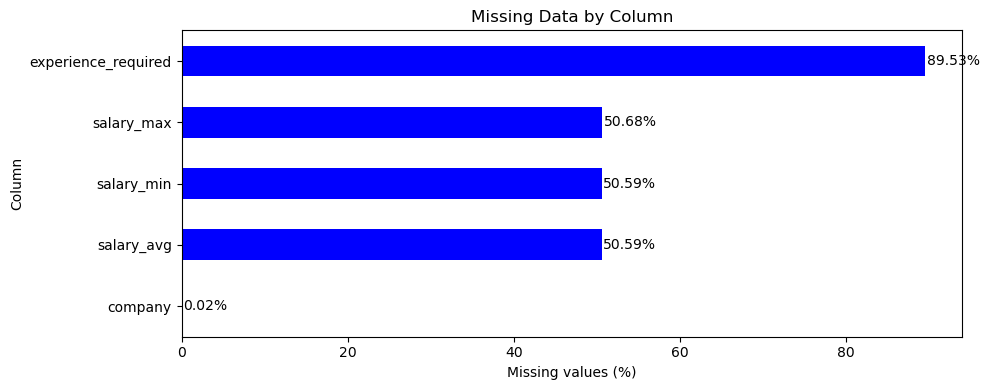

In [9]:
# Create the data-quality summary table

# Check data type of each column
data_type = raw.dtypes.astype(str)

# Count missing values in each column
missing_count = raw.isna().sum()

# Calculate percentage of missing values
missing_pct = (raw.isna().sum() / len(raw)) * 100
missing_pct = missing_pct.round(2)

# Count unique values in each column
distinct_count = raw.nunique(dropna=False)


qlty_profile = pd.DataFrame({
    "dtype": data_type,
    "missing_count": missing_count,
    "missing_pct": missing_pct,
    "distinct_count": distinct_count
}).sort_values(["missing_pct", "distinct_count"], ascending=[False, False])

display(qlty_profile)

# Visualize how complete each column is
missing_data = qlty_profile[qlty_profile["missing_pct"] > 0].sort_values(
    "missing_pct"
)

ax = missing_data["missing_pct"].plot(
    kind="barh",
    figsize=(10, 4),
    color="blue"
)

ax.set_title("Missing Data by Column")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Column")

# Display values on graph
for bar in ax.patches:
    value = bar.get_width()
    ax.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

**Insight:** 

`experience_required` is missing for most rows, while a zero-length skills list may mean "nothing was found to be missing when parsing" rather than "the job requires no skills." 

**Preserve and assess experience information**

The `experience_required` column contains 89.53% of missing job postings and contains unusually large values that may represent months rather than years.
Rather than dropping the column will be retained in the Silver dataset for further investigation and secondary analysis. It will not be included in the initial regression model until its units and reliability have been investigated.

**Note:**

Since ´experience_required´ is the number of years of experience required for the role, there are values that look implausible. Therefore, we will categorize values that are above 35 years of work experience as the threshold and flag them as plausible values.

In [10]:
# Convert experience_required to numeric
df["experience_required"] = pd.to_numeric(
    df["experience_required"], errors="coerce"
)

# Categorize missing values
df["experience_missing"] = (df["experience_required"].isna())

# Flag unrealistic experience (>35 years) values as invalid
df["experience_invalid"] = df["experience_required"] > 35

# Replace unrealistic values with missing
df.loc[df["experience_invalid"], "experience_required"] = np.nan

print("Invalid experience values:", df["experience_invalid"].sum())
print("Missing experience values after cleaning:", df["experience_missing"].sum())
print(df["experience_required"].describe())

Invalid experience values: 55
Missing experience values after cleaning: 4166
count   432.00
mean      8.06
std       5.91
min       1.00
25%       5.00
50%       6.00
75%      10.00
max      35.00
Name: experience_required, dtype: float64


**Cleaning and Categorizing Experience:**

Experience values between 0 and 30 are provisionally retained as plausible years of experience. Values outside this range are excluded from the cleaned field but preserved in the original column for auditing.

Two separate indicators distinguish genuinely missing values from reported values rejected by the cleaning rule. Valid experience values are then grouped into four interpretable tiers for EDA and optional modelling.

Because the original experience extraction may contain errors and exhibit substantial missingness, it is being treated as experimental rather than automatically included in the baseline model.

In [11]:
print(df.columns.tolist())

['job_id', 'job_title', 'company', 'location', 'salary_min', 'salary_max', 'description', 'country', 'search_keyword', 'experience_required', 'degree_required', 'skills', 'num_skills', 'job_level', 'is_remote', 'salary_avg', 'has_salary', 'experience_missing', 'experience_invalid']


In [12]:
print("Originally missing:")
print(df["experience_missing"].value_counts())

print("\nInvalid experience:")
print(df["experience_invalid"].value_counts())

Originally missing:
experience_missing
True     4166
False     487
Name: count, dtype: int64

Invalid experience:
experience_invalid
False    4598
True       55
Name: count, dtype: int64


In [13]:
display(
    df.loc[
        df["experience_invalid"],
        ["experience_required", "experience_missing", "experience_invalid"]
    ]
)

,experience_required,experience_missing,experience_invalid
6,NaN,False,True
83,NaN,False,True
87,NaN,False,True
229,NaN,False,True
301,NaN,False,True
310,NaN,False,True
314,NaN,False,True
323,NaN,False,True
344,NaN,False,True
533,NaN,False,True


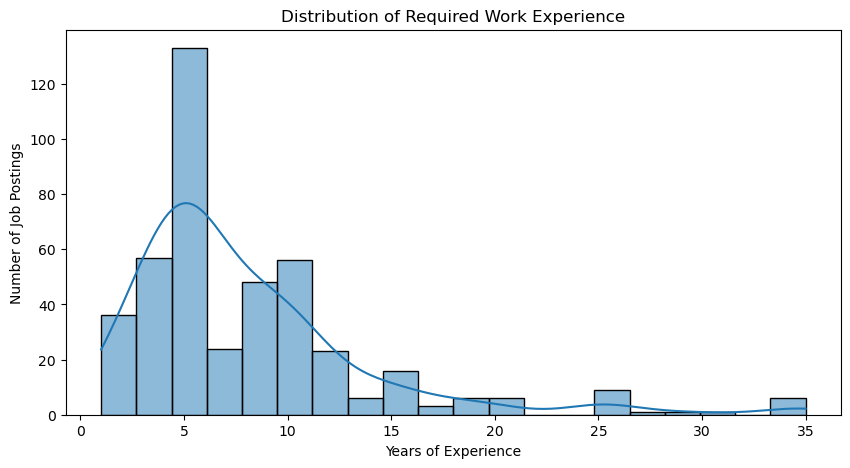

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="experience_required",
    bins=20,
    kde=True
)

plt.title("Distribution of Required Work Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Job Postings")

plt.show()

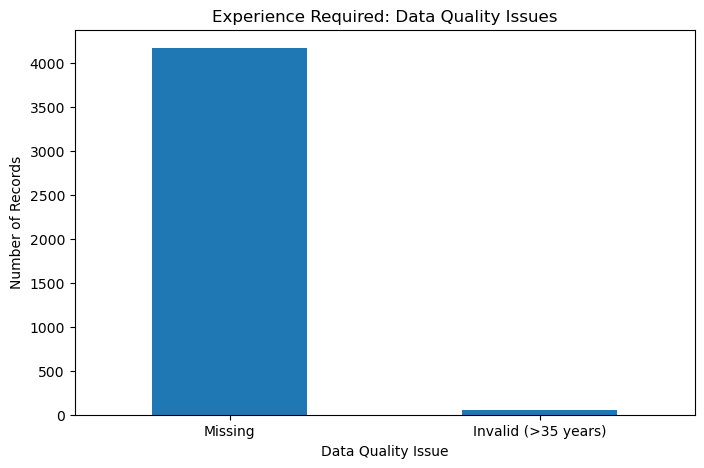

In [15]:
experience_quality = pd.Series({
    "Missing": df["experience_missing"].sum(),
    "Invalid (>35 years)": df["experience_invalid"].sum()
})

experience_quality.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Experience Required: Data Quality Issues")
plt.xlabel("Data Quality Issue")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.show()

#### Checking Duplicates

In [16]:
# Identify repeated postings using the main advertisement details
duplicate_columns = [
    "job_title",
    "company",
    "location",
    "country",
    "description",
]

# Creating a duplicate-checking dataset
duplicate_check = df.copy()

# Create the Boolean mask from duplicate_check
repeated_postings = duplicate_check.duplicated(
    subset=duplicate_columns,
    keep=False,
)

# Display the possible repeated postings for inspection
display(
    df.loc[
        repeated_postings,
        [            
            "job_title",
            "company",
            "location",
            "country",
            "skills",
            "job_level",
            "is_remote",
            "salary_avg",
        ]
    ].sort_values(["company", "job_title"])
)


,job_title,company,location,country,skills,job_level,is_remote,salary_avg
3661,healthcare business analyst,ARC Business Solutions,"Calgary, Calgary region",Canada,[],Mid,False,NaN
3662,healthcare business analyst,ARC Business Solutions,"Calgary, Calgary region",Canada,[],Mid,False,NaN
2617,machine learning engineer ii behavioral securi...,Abnormal,UK,UK,['machine learning'],Mid,False,"107,784.87"
2621,machine learning engineer ii behavioral securi...,Abnormal,UK,UK,['machine learning'],Mid,False,"95,008.02"
1349,lead data engineer,Capital One,"Pimmit, Fairfax County",USA,[],Lead,False,"203,131.94"
...,...,...,...,...,...,...,...,...
2594,"staff machine learning engineer, simulation",Waymo,"London, UK",UK,[],Mid,False,"156,000.00"
3409,machine learning engineer iii / senior machine...,Workday,"Toronto, Ontario",Canada,[],Senior,False,"195,000.00"
3412,machine learning engineer iii / senior machine...,Workday,"Toronto, Ontario",Canada,[],Senior,False,"195,000.00"
3440,senior machine learning engineer,Workday,"Toronto, Ontario",Canada,[],Mid,False,"195,000.00"


**Non-Conflicting Duplicate Groups:**

The review identified 19 repeated-posting groups with no conflicting salary, job-level, or remote-status information. One representative record was retained from each group, while missing salary values remained unchanged and were not imputed.

In [17]:
# Identify all rows belonging to possible duplicate groups
repeated_postings = duplicate_check.duplicated(
    subset=duplicate_columns,
    keep=False,
)


# Group matching postings and identify conflicting information
groups = duplicate_check.groupby(
    duplicate_columns,
    dropna=False,
)

duplicate_check["salary_conflict"] = (
    groups["salary_avg"].transform("nunique") > 1
)

duplicate_check["job_level_conflict"] = (
    groups["job_level"].transform("nunique") > 1
)

duplicate_check["remote_conflict"] = (
    groups["is_remote"].transform("nunique") > 1
)

duplicate_check["needs_review"] = (
    duplicate_check["salary_conflict"]
    | duplicate_check["job_level_conflict"]
    | duplicate_check["remote_conflict"]
)


# Preserve conflicting groups separately for reference
conflict_review = duplicate_check.loc[
    repeated_postings
    & duplicate_check["needs_review"]
].copy()


display(
    conflict_review.sort_values(
        ["company", "job_title"]
    )
)

,job_id,job_title,company,location,salary_min,salary_max,description,country,search_keyword,experience_required,degree_required,skills,num_skills,job_level,is_remote,salary_avg,has_salary,experience_missing,experience_invalid,salary_conflict,job_level_conflict,remote_conflict,needs_review
2617,5704471626,machine learning engineer ii behavioral securi...,Abnormal,UK,"107,784.87","107,784.87",Abnormal AI is looking for a Machine Learning ...,UK,machine learning engineer,NaN,Not specified,['machine learning'],1,Mid,False,"107,784.87",True,True,False,True,False,False,True
2621,5696595574,machine learning engineer ii behavioral securi...,Abnormal,UK,"95,008.02","95,008.02",Abnormal AI is looking for a Machine Learning ...,UK,machine learning engineer,NaN,Not specified,['machine learning'],1,Mid,False,"95,008.02",True,True,False,True,False,False,True
1349,5680352984,lead data engineer,Capital One,"Pimmit, Fairfax County","203,131.94","203,131.94",Lead Data Engineer Do you love building and pi...,USA,data engineer,NaN,Not specified,[],0,Lead,False,"203,131.94",True,True,False,True,False,False,True
1356,5680352972,lead data engineer,Capital One,"Pimmit, Fairfax County","191,532.03","191,532.03",Lead Data Engineer Do you love building and pi...,USA,data engineer,NaN,Not specified,[],0,Lead,False,"191,532.03",True,True,False,True,False,False,True
1370,5684617242,lead data engineer,Capital One,"Pimmit, Fairfax County","160,245.72","160,245.72",Lead Data Engineer Do you love building and pi...,USA,data engineer,NaN,Not specified,[],0,Lead,False,"160,245.72",True,True,False,True,False,False,True
1498,5703050242,lead machine learning engineer,Capital One,"Grand Central, Manhattan","216,889.60","216,889.60",Lead Machine Learning Engineer As a Capital On...,USA,machine learning engineer,NaN,Not specified,['machine learning'],1,Lead,False,"216,889.60",True,True,False,True,False,False,True
1500,5703050752,lead machine learning engineer,Capital One,"Pimmit, Fairfax County","175,475.45","175,475.45",Lead Machine Learning Engineer As a Capital On...,USA,machine learning engineer,NaN,Not specified,['machine learning'],1,Lead,False,"175,475.45",True,True,False,True,False,False,True
1502,5680364006,lead machine learning engineer,Capital One,"Pimmit, Fairfax County","163,572.34","163,572.34",Lead Machine Learning Engineer As a Capital On...,USA,machine learning engineer,NaN,Not specified,['machine learning'],1,Lead,False,"163,572.34",True,True,False,True,False,False,True
1604,5709910086,lead machine learning engineer,Capital One,"Grand Central, Manhattan","218,855.60","218,855.60",Lead Machine Learning Engineer As a Capital On...,USA,machine learning engineer,NaN,Not specified,['machine learning'],1,Lead,False,"218,855.60",True,True,False,True,False,False,True
1605,5704138522,lead machine learning engineer,Capital One,"Grand Central, Manhattan","234,743.60","234,743.60",Lead Machine Learning Engineer As a Capital On...,USA,machine learning engineer,NaN,Not specified,['machine learning'],1,Lead,False,"234,743.60",True,True,False,True,False,False,True


**Conflicting Duplicate Groups:**

The review identified 35 rows across 13 repeated-posting groups with inconsistent information. Thirty-three rows belonged to groups with different salary values, while two Workday records had conflicting job levels. No remote-status conflicts were found. Because these differences could not be resolved confidently, the affected rows were preserved separately and excluded from the cleaned dataset.

##### Create one-record-per-posting data

In [18]:
# Exclude conflicting groups from the cleaned dataset
deduplication_work = duplicate_check.loc[
    ~duplicate_check["needs_review"]
].copy()


# Prefer a row containing salary when another copy has missing salary
deduplication_work["_has_salary"] = (
    deduplication_work["salary_avg"].notna()
)


# Keep one record from each non-conflicting duplicate group
df_clean = (
    deduplication_work
    .sort_values("_has_salary", ascending=False)
    .drop_duplicates(
        subset=duplicate_columns,
        keep="first",
    )
    .sort_index()
    .drop(
        columns=[
            "_has_salary",
            "salary_conflict",
            "job_level_conflict",
            "remote_conflict",
            "needs_review",
        ]
    )
    .copy()
)


# Confirm that duplicate handling worked
assert not df_clean.duplicated(
    subset=duplicate_columns
).any()


print(f"Rows before duplicate handling: {len(duplicate_check):,}")
print(f"Possible duplicate rows: {repeated_postings.sum():,}")
print(f"Conflicting rows excluded: {len(conflict_review):,}")
print(f"Rows in cleaned dataset: {len(df_clean):,}")
print(f"Total rows removed: {len(duplicate_check) - len(df_clean):,}")


# Continue subsequent analysis with the cleaned data
# df = df_clean.copy()

Rows before duplicate handling: 4,653
Possible duplicate rows: 75
Conflicting rows excluded: 35
Rows in cleaned dataset: 4,597
Total rows removed: 56


**Creating the Final Deduplicated Dataset:**

Conflicting duplicate groups were excluded from the cleaned dataset. For each remaining repeated-posting group, one representative record was retained, with preference given to a row containing salary information. A final validation confirmed that no repeated postings remained, and the resulting dataset became the working data for subsequent analysis.

#### Validating Salary values

In [19]:
# Validate salary values before currency conversion
salary_columns = ["salary_min", "salary_avg", "salary_max"]

# Find zeros or negative salary values
non_positive_salary = (
    df[salary_columns].le(0).any(axis=1)
)

# To check salaries that do not follow the order: salary_min <= salary_avg <= salary_max
complete_salary = df[
    ["salary_min", "salary_avg", "salary_max"]
].notna().all(axis=1)

invalid_salary_order = complete_salary & ~(
    df["salary_min"].le(df["salary_avg"])
    & df["salary_avg"].le(df["salary_max"])           
)

# Confirm that has_salary agrees with salary availability
incorrect_salary_flag =(
    df["has_salary"].ne(df["salary_avg"].notna())
)

print(f"Rows with non-positive salary components: {non_positive_salary.sum():,}")
print(f"Rows with invalid salary order: {invalid_salary_order.sum():,}")
print(f"Rows where has_salary disagrees with salary_avg: {incorrect_salary_flag.sum():,}")

Rows with non-positive salary components: 11
Rows with invalid salary order: 0
Rows where has_salary disagrees with salary_avg: 4


In [20]:
# Combine all salary-quality problems
salary_issue_mask = (
    non_positive_salary
    | invalid_salary_order
    | incorrect_salary_flag
)

salary_issue_review = df.loc[
    salary_issue_mask,
    [
        "job_id",
        "job_title",
        "company",
        "country",
        "salary_min",
        "salary_avg",
        "salary_max",
        "has_salary",
    ]
].copy()


# Show why each row was flagged
salary_issue_review["non_positive_salary"] = (
    non_positive_salary
)

salary_issue_review["invalid_salary_order"] = (
    invalid_salary_order
)

salary_issue_review["incorrect_salary_flag"] = (
    incorrect_salary_flag
)


print(
    f"Unique rows with salary-quality issues: "
    f"{len(salary_issue_review):,}"
)

display(salary_issue_review)

Unique rows with salary-quality issues: 15


,job_id,job_title,company,country,salary_min,salary_avg,salary_max,has_salary,non_positive_salary,invalid_salary_order,incorrect_salary_flag
667,2549478979,machine learning engineer,Artifex HR,India,0.00,"400,000.00","800,000.00",True,True,False,False
682,2658062217,machine learning engineer,CES Information Technologies,India,0.00,"750,000.00","1,500,000.00",True,True,False,False
684,2475263628,machine learning engineer,Hammoq,India,0.00,"450,000.00","900,000.00",True,True,False,False
687,2383302553,machine learning engineer,SIlverPeople Consulting,India,0.00,"1,350,000.00","2,700,000.00",True,True,False,False
690,2177266537,machine learning engineer,Marktine,India,0.00,"750,000.00","1,500,000.00",True,True,False,False
901,1788701062,business analyst,Presidency University,India,0.00,"250,000.00","500,000.00",True,True,False,False
905,2609531597,business analyst,Texila American University,India,0.00,"350,000.00","700,000.00",True,True,False,False
3129,5703188331,"data analyst – etl, sql",Astra North Infoteck Inc.,Canada,"10,000.00","10,000.00",NaN,False,False,False,True
3153,5702814416,senior business data analyst,Loblaw Companies,Canada,0.00,41.00,82.00,True,True,False,False
3200,5707869833,data engineer,SereneAid,Canada,"10,000.00","10,000.00",NaN,False,False,False,True


#### Resolve salary issues

In [21]:
# Preserve the questionable salary records before making changes
salary_issue_review = df.loc[
    non_positive_salary | invalid_salary_order | incorrect_salary_flag
].copy()

# Identify unreliable salary values 
invalid_salary_record = (non_positive_salary | invalid_salary_order)

# Replace unreliable salary values with missing values
# The job posting itself is not removed
df.loc[invalid_salary_record, 
    ["salary_min", "salary_avg", "salary_max"]] = np.nan

# Recalculate salary availability from the cleaned target
df["has_salary"] = (
    df["salary_avg"].notna() & df["salary_avg"].gt(0)
)

In [22]:
# Repeat salary-quality check
remaining_non_positive = (
    df[["salary_min", "salary_avg", "salary_max"]].le(0).any(axis=1)
)

complete_salary = (
    df[["salary_min", "salary_avg", "salary_max"]]
    .notna().all(axis=1)
)

remaining_invalid_salary_order =(
    complete_salary & ~(
        df["salary_min"].le(df["salary_avg"])
        & df["salary_avg"].le(df["salary_max"])
    )
)

remaining_incorrect_salary = (
    df["has_salary"] != (df["salary_avg"].notna())
)


print(f"Remaining non-positive salaries: {remaining_non_positive.sum():,}")
print(f"Reminaing invalid salary order: {remaining_invalid_salary_order.sum():,}")
print(f"Remaining incorrect salary: {remaining_incorrect_salary.sum():,}")

Remaining non-positive salaries: 0
Reminaing invalid salary order: 0
Remaining incorrect salary: 0


**Resolving Salary-Quality Issues:**

Non-positive and incorrectly ordered salary values were treated as unreliable and replaced with missing values `NaN` rather than being estimated. The associated job postings were retained for non-salary analysis. The `has_salary` field was then recalculated from the cleaned average salary, while the original questionable records were preserved separately for reference.

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               4653 non-null   int64  
 1   job_title            4653 non-null   string 
 2   company              4652 non-null   string 
 3   location             4653 non-null   string 
 4   salary_min           2288 non-null   float64
 5   salary_max           2284 non-null   float64
 6   description          4653 non-null   string 
 7   country              4653 non-null   string 
 8   search_keyword       4653 non-null   string 
 9   experience_required  432 non-null    float64
 10  degree_required      4653 non-null   string 
 11  skills               4653 non-null   string 
 12  num_skills           4653 non-null   int64  
 13  job_level            4653 non-null   string 
 14  is_remote            4653 non-null   bool   
 15  salary_avg           2288 non-null   f

### Standardize salary currency
The dataset combines salaries reported in different local currencies. For example, a salary of `1,000,000` in India is not directly comparable to `1,000,000` in the United States.
Because the business evaluates the model's **Mean Absolute Error (MAE)** in US dollars, salaries are converted into a consistent **2024 USD target**.
The fixed conversion table uses rounded 2024 official exchange rates, expressed as **local currency units per US dollar**, from the [World Bank indicator PA.NUS.FCRF](https://data.worldbank.org/indicator/PA.NUS.FCRF?name_desc=true).
Using fixed and properly sourced exchange rates makes the notebook reproducible. In a production environment, these rates would be maintained in a version-controlled reference table.

In [24]:
# Create a reference dictionary containing each country's currency code
# and its 2024 exchange rate
#
# lcu_per_usd means "local currency units per 1 USD"

country_currency = {
    "USA": {"currency": "USD", "lcu_per_usd": 1.00},
    "UK": {"currency": "GBP", "lcu_per_usd": 0.78},
    "Canada": {"currency": "CAD", "lcu_per_usd": 1.37},
    "India": {"currency": "INR", "lcu_per_usd": 83.67},
    "Australia": {"currency": "AUD", "lcu_per_usd": 1.52},
}


# Convert dictionary into DataFrame
currency_reference = (
    pd.DataFrame.from_dict(country_currency, orient="index")
    .rename_axis("country")
    .reset_index()
)
display(currency_reference)


# Create a new enriched dataset from cleaned working data
silver = df.copy()


# Assign appropriate currency code to each record by country of advertised job
silver["currency"] = silver["country"].map(
    {country: values["currency"] for country, values in country_currency.items()}
)
silver["lcu_per_usd"] = silver["country"].map(
    {country: values["lcu_per_usd"] for country, values in country_currency.items()}
)


# Convert minimum, maximum, & average salaries to USD
for source_column in ["salary_min", "salary_max", "salary_avg"]:
    silver[f"{source_column}_local"] = silver[source_column]           # Preserve original local currency salary
    silver[f"{source_column}_usd"] = (
        silver[source_column] / silver["lcu_per_usd"]
    )                                                                  # Convert lcu to USD


# Recalculate salary availability using USD target
silver["has_salary"] = (
    silver["salary_avg_usd"].notna() 
    & silver["salary_avg_usd"].gt(0)
)


# Summarize salary availability & median salaries by Country
# Use median because it is less affected by unusually high and low salaries
# and is better used for skewed distribution
country_salary_comparison = silver.groupby(["country","job_level"]).agg(
    labeled_rows=("salary_avg", "count"),
    median_local_salary=("salary_avg_local", "median"),
    median_usd_salary=("salary_avg_usd", "median"),
).round(2)


display(country_salary_comparison)

,country,currency,lcu_per_usd
0,USA,USD,1.00
1,UK,GBP,0.78
2,Canada,CAD,1.37
3,India,INR,83.67
4,Australia,AUD,1.52


labeled_rows  median_local_salary  median_usd_salary
country   job_level                                                      
Australia Junior                0                  NaN                NaN
          Lead                  3           210,000.00         138,157.89
          Mid                  72           143,994.50          94,733.22
          Senior               20           204,750.00         134,703.95
Canada    Junior                0                  NaN                NaN
          Lead                 12           132,337.50          96,596.72
          Mid                 156            97,000.00          70,802.92
          Senior               70           129,000.00          94,160.58
India     Junior                0                  NaN                NaN
          Lead                  0                  NaN                NaN
          Mid                  55         1,200,000.00          14,342.06
          Senior                1         1,800,000.00          21,513.09
UK        Junior               40            34,384.59          44,082.81
          Lead                 51            68,737.62          88,125.15
          Mid                 747            46,183.43          59,209.53
          Senior              111            66,774.75          85,608.65
USA       Lead                 33           167,806.88         167,806.88
          Mid                 856           121,315.98         121,315.98
          Senior               61           142,932.62         142,932.62

**Insight:**

A country-to-currency reference table was created using fixed 2024 exchange rates expressed as local currency units per US dollar. The original local-currency salary values were preserved, while additional columns were created for their USD equivalents.
The conversion was calculated as:
**USD salary = Local salary ÷ Local currency units per US dollar**
A validation check was included to identify countries without a matching exchange rate. Finally, median local and USD salaries were compared by country. The median was used because it is less affected by unusually high or low salary values.

### Parse and Flatten Skills

In [25]:
# Parse through all listed skills by creating a function that
# Converts text-formatted lists into actual Python lists
def parse_skills(value):
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    try:
        return [
            str(skill).strip().lower()
            for skill in ast.literal_eval(value)
        ]
    except (ValueError, SyntaxError):
        return []


silver["skills_list"] = silver["skills"].map(parse_skills)


# Find every individual skill in the dataset
all_skills = sorted({
    skill
    for skills in silver["skills_list"]
    for skill in skills
})

print(all_skills)

['aws', 'excel', 'machine learning', 'power bi', 'python', 'spark', 'sql', 'tableau']


In [26]:
# Create one binary column for every individual skill
for skill in all_skills:
    column_name = "skill_" + skill.replace(" ", "_")

    silver[column_name] = (
        silver["skills_list"]
        .map(lambda skills: int(skill in skills))
    )

# Distinguish postings with extracted skills from empty skill lists
silver["skills_extracted"] = (
    silver["skills_list"].str.len().gt(0).astype(int)
)

**Insight:**
Each parsed skill is converted into a binary feature so that the model can identify
which specific skills are associated with salary. Multiple skills that are
present in the same posting are processed using **multi-hot encoding**.

In [27]:
silver.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  4653 non-null   int64  
 1   job_title               4653 non-null   string 
 2   company                 4652 non-null   string 
 3   location                4653 non-null   string 
 4   salary_min              2288 non-null   float64
 5   salary_max              2284 non-null   float64
 6   description             4653 non-null   string 
 7   country                 4653 non-null   string 
 8   search_keyword          4653 non-null   string 
 9   experience_required     432 non-null    float64
 10  degree_required         4653 non-null   string 
 11  skills                  4653 non-null   string 
 12  num_skills              4653 non-null   int64  
 13  job_level               4653 non-null   string 
 14  is_remote               4653 non-null   

In [29]:
# Records available for salary EDA and future modelling
training_candidates = silver.loc[
    silver["has_salary"]
].copy()


# Records without a valid salary target
scoring_pool = silver.loc[
    ~silver["has_salary"]
].copy()


print(f"All cleaned postings: {len(silver):,}")
print(f"Postings with valid salaries: {len(training_candidates):,}")
print(f"Postings without valid salaries: {len(scoring_pool):,}")

assert len(training_candidates) + len(scoring_pool) == len(silver)

All cleaned postings: 4,653
Postings with valid salaries: 2,288
Postings without valid salaries: 2,365


## Data Preprocessing
### Training salary model
- divide the dataset into labels (X) and target (y)
- divide the dataset into train and test
- Ensure both X_train and y_train are in 2 dimension

In [32]:
# Preserve the original reported salary
silver["salary_avg_reported"] = silver["salary_avg"]


# Salary is available when the converted value is positive
silver["has_salary"] = (
    silver["salary_avg_usd"].notna()
    & silver["salary_avg_usd"].gt(0)
)


# Records used to train the salary model
training_candidates = silver.loc[
    silver["has_salary"]
].copy()


# Records requiring salary predictions
scoring_pool = silver.loc[
    ~silver["has_salary"]
].copy()


# Final prediction target
y = training_candidates["salary_avg_usd"]

In [33]:
print(training_candidates.head())

         job_id                  job_title            company  \
631  3175702626  machine learning engineer  Marj Technologies   
634  4514376236  machine learning engineer              Qrata   
635  5552722462  machine learning engineer    Innover Systems   
636  3987216053  machine learning engineer              Thena   
637  4708090721  machine learning engineer       LMES Academy   

                 location   salary_min   salary_max  \
631      Noida, Ghaziabad   700,000.00 1,000,000.00   
634  Bangalore, Karnataka 1,700,000.00 4,000,000.00   
635     Pune, Maharashtra   400,000.00 1,000,000.00   
636  Bangalore, Karnataka 1,500,000.00 2,400,000.00   
637   Chennai, Tamil Nadu   700,000.00 1,500,000.00   

                                           description country  \
631  Job Description We are looking for a highly ca...   India   
634  Role: Machine Learning Engineer As a machine l...   India   
635  Position: Machine Learning Engineer Job Type: ...   India   
636  We at The

### Exploratory Data Analysis

In [35]:
silver.describe()

,job_id,salary_min,salary_max,experience_required,num_skills,salary_avg,experience_required_clean,lcu_per_usd,salary_min_local,salary_min_usd,salary_max_local,salary_max_usd,salary_avg_local,salary_avg_usd,skill_aws,skill_excel,skill_machine_learning,skill_power_bi,skill_python,skill_spark,skill_sql,skill_tableau,skills_extracted,salary_avg_reported
count,"4,653.00","2,288.00","2,284.00",487.00,"4,653.00","2,288.00",426.00,"4,653.00","2,288.00","2,288.00","2,284.00","2,284.00","2,288.00","2,288.00","4,653.00","4,653.00","4,653.00","4,653.00","4,653.00","4,653.00","4,653.00","4,653.00","4,653.00","2,288.00"
mean,"5,639,828,862.93","117,745.58","146,033.75",23.97,0.38,"131,770.76",7.68,17.40,"117,745.58","96,622.94","146,033.75","102,547.26","131,770.76","99,501.84",0.02,0.04,0.17,0.01,0.06,0.02,0.06,0.00,0.30,"131,770.76"
std,"309,477,868.12","182,941.50","339,556.47",60.68,0.68,"253,844.06",5.03,32.81,"182,941.50","54,430.76","339,556.47","54,171.74","253,844.06","53,907.27",0.15,0.20,0.38,0.09,0.24,0.13,0.23,0.07,0.46,"253,844.06"
min,"1,155,088,318.00",9.00,11.00,1.00,0.00,10.00,1.00,0.78,9.00,0.14,11.00,1.72,10.00,0.93,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,10.00
25%,"5,679,736,925.00","53,885.76","57,235.60",5.00,0.00,"55,099.02",5.00,1.00,"53,885.76","57,692.31","57,235.60","63,400.35","55,099.02","60,380.91",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"55,099.02"
50%,"5,696,177,587.00","83,631.83","90,521.18",7.00,0.00,"88,100.27",6.00,1.37,"83,631.83","84,387.89","90,521.18","90,666.19","88,100.27","87,151.56",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"88,100.27"
75%,"5,704,005,297.00","136,378.38","144,418.07",12.00,1.00,"140,000.00",10.00,1.52,"136,378.38","124,424.09","144,418.07","131,022.54","140,000.00","128,282.07",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,"140,000.00"
max,"5,711,046,284.00","3,000,000.00","7,000,000.00",360.00,5.00,"4,500,000.00",30.00,83.67,"3,000,000.00","368,271.97","7,000,000.00","368,271.97","4,500,000.00","368,271.97",1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,"4,500,000.00"


### Univariate Analysis
***Analytical question:*** What is the distribution of ´salary_avg´?

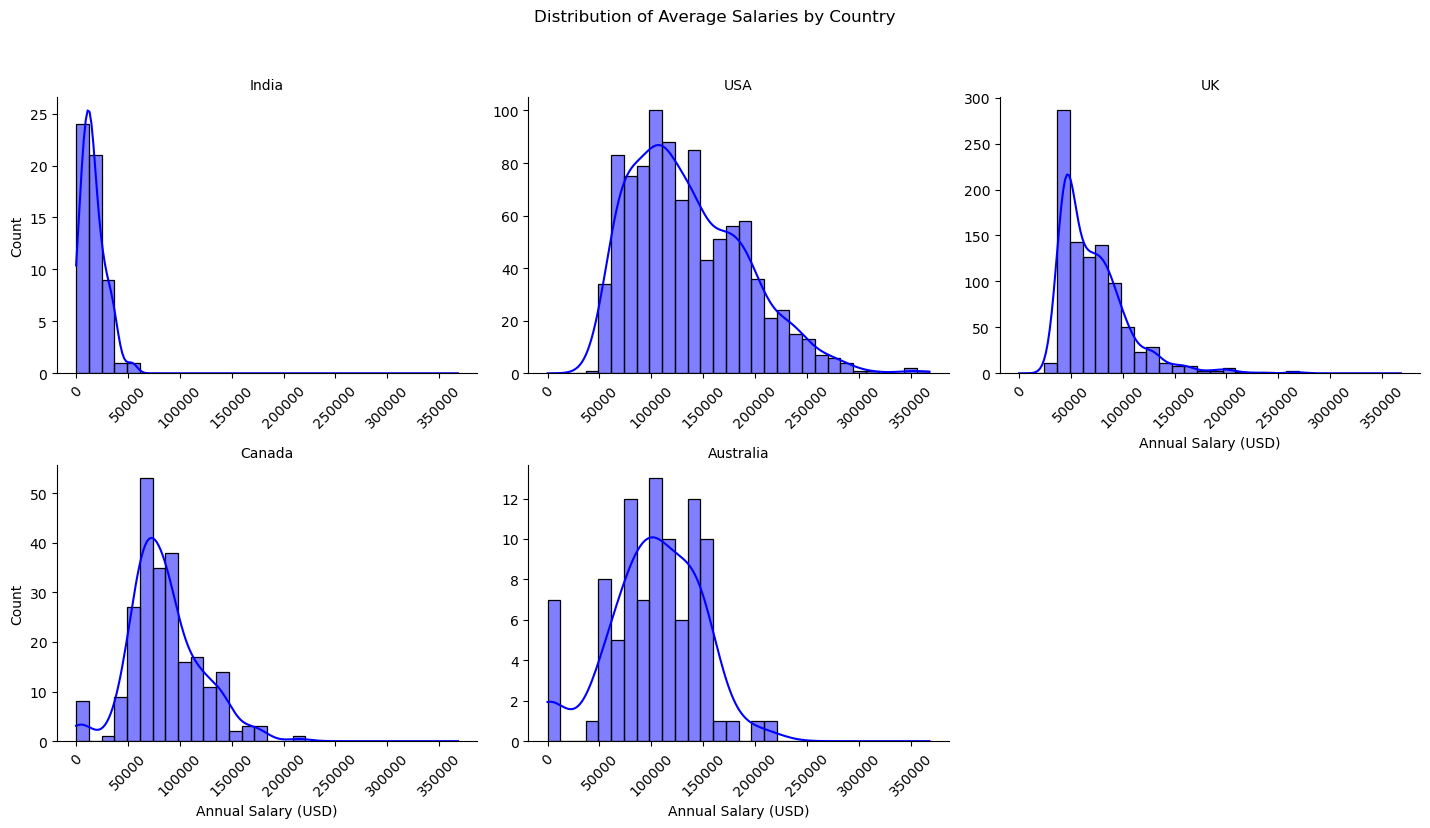

In [36]:
# Keep only valid positive salaries
salary_plot = (
    silver.loc[
        silver["salary_avg_usd"].gt(0),
        ["country", "salary_avg_usd"]
    ]
    .dropna()
)

# Distribution plot
chart = sns.displot(
    data=salary_plot,
    x="salary_avg_usd",
    col="country",
    col_wrap=3,
    bins=30,
    kde=True,
    color="blue",
    height=4,
    aspect=1.2,
    facet_kws={
        "sharex": False,
        "sharey": False
    }
)

# Labels
chart.set_axis_labels(
    "Annual Salary (USD)"
    )

chart.set_titles("{col_name}")

# Rotate x-axis labels for every subplot
for ax in chart.axes.flatten():
    ax.tick_params(axis="x", rotation=45)

# Overall title
chart.fig.suptitle(
    "Distribution of Average Salaries by Country",
    y=1.03
)

plt.tight_layout()
plt.show()

**Insight**
Salary skewness for India, 

In [37]:
# Summarize & calculate Skewness for each country
salary_summary = (
    salary_plot.groupby("country")
    .agg(
        salary_records=("salary_avg_usd", "count"),
        mean_salary=("salary_avg_usd", "mean"),
        median_salary=("salary_avg_usd", "median"),
        minimum_salary=("salary_avg_usd", "min"),
        maximum_salary=("salary_avg_usd", "max"),
        skewness=("salary_avg_usd", "skew"),
    )
    .round(2)
)

display(salary_summary)

,salary_records,mean_salary,median_salary,minimum_salary,maximum_salary,skewness
country,,,,,,
Australia,95,"102,344.73","105,263.16",6.58,"213,815.79",-0.42
Canada,238,"85,421.19","80,291.97",56.57,"214,963.50",0.49
India,56,"16,470.44","14,640.85",0.93,"53,782.72",0.97
UK,949,"71,831.49","64,477.86","30,927.71","266,666.67",1.83
USA,950,"135,280.84","126,332.88","43,449.42","368,271.97",0.76


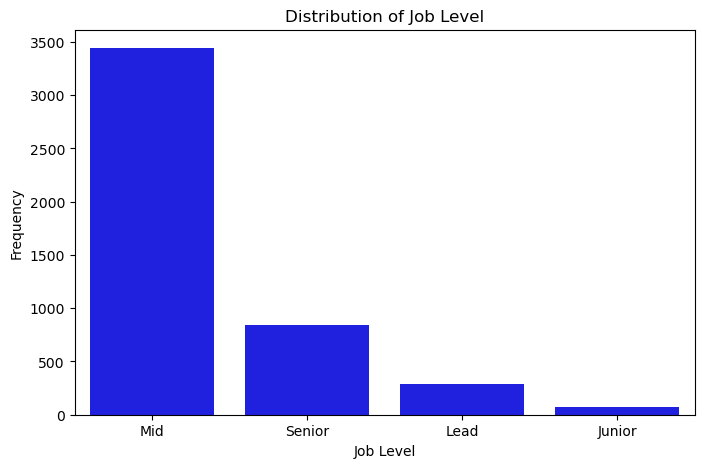

In [38]:
# Distribution of Job level
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="job_level",
    color="blue",
    order=df["job_level"].value_counts().index
)

plt.title("Distribution of Job Level")
plt.xlabel("Job Level")
plt.ylabel("Frequency")

plt.show()


### Bivariate Analysis

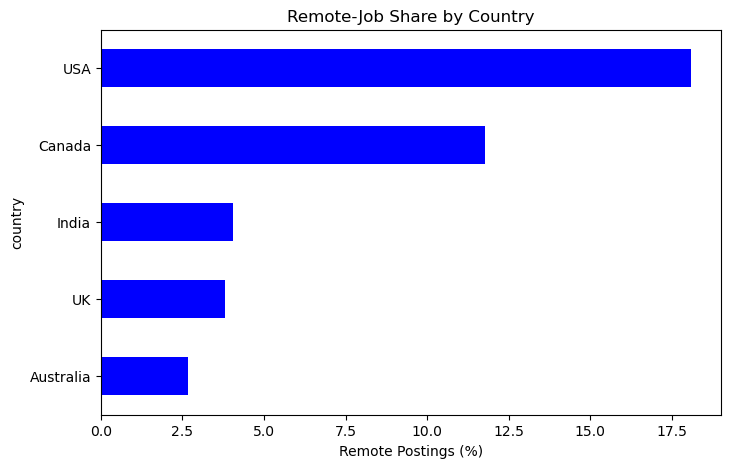

In [39]:
# Evaluating Remote Job postings by Country
remote_share = (
    silver.groupby("country")["is_remote"]
    .mean()
    .mul(100)
    .sort_values()
)

remote_share.plot(
    kind="barh",
    color="blue",
    figsize=(8, 5)
)

plt.title("Remote-Job Share by Country")
plt.xlabel("Remote Postings (%)")
plt.show()

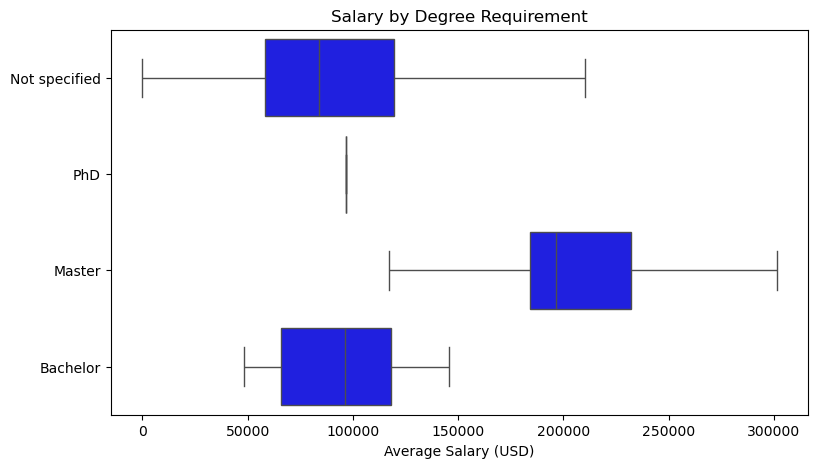

In [40]:
# Categorizing Salary by Degree Requirement 
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=silver,
    x="salary_avg_usd",
    y="degree_required",
    showfliers=False,
    color="blue"
)

plt.title("Salary by Degree Requirement")
plt.xlabel("Average Salary (USD)")
plt.ylabel("")
plt.show()

### Multivariate Analysis

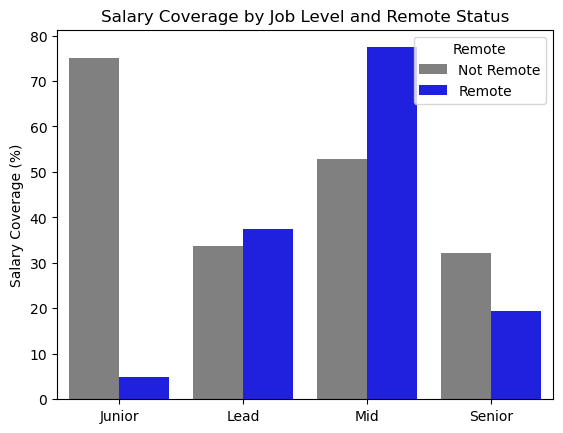

In [41]:

# Calculate salary coverage by job level and remote status
coverage_group = (
    silver.groupby(
        ["job_level", "is_remote"],
        observed=True
    )["has_salary"]
    .mean()
    .mul(100)
    .reset_index(name="coverage_pct")
)

# Give the Boolean values readable labels
coverage_group["remote_status"] = (
    coverage_group["is_remote"]
    .map({True: "Remote", False: "Not Remote"})
)

# Plot salary coverage
sns.barplot(
    data=coverage_group,
    x="job_level",
    y="coverage_pct",
    hue="remote_status",    
    palette={
        "Remote": "blue",
        "Not Remote": "grey"
    }
)

plt.title("Salary Coverage by Job Level and Remote Status")
plt.ylabel("Salary Coverage (%)")
plt.xlabel("")
plt.legend(title="Remote")
plt.show()

,country,total_postings,remote_postings,remote_share_pct
0,USA,950,172,18.11
1,UK,949,36,3.79
2,Canada,935,110,11.76
3,India,916,37,4.04
4,Australia,903,24,2.66


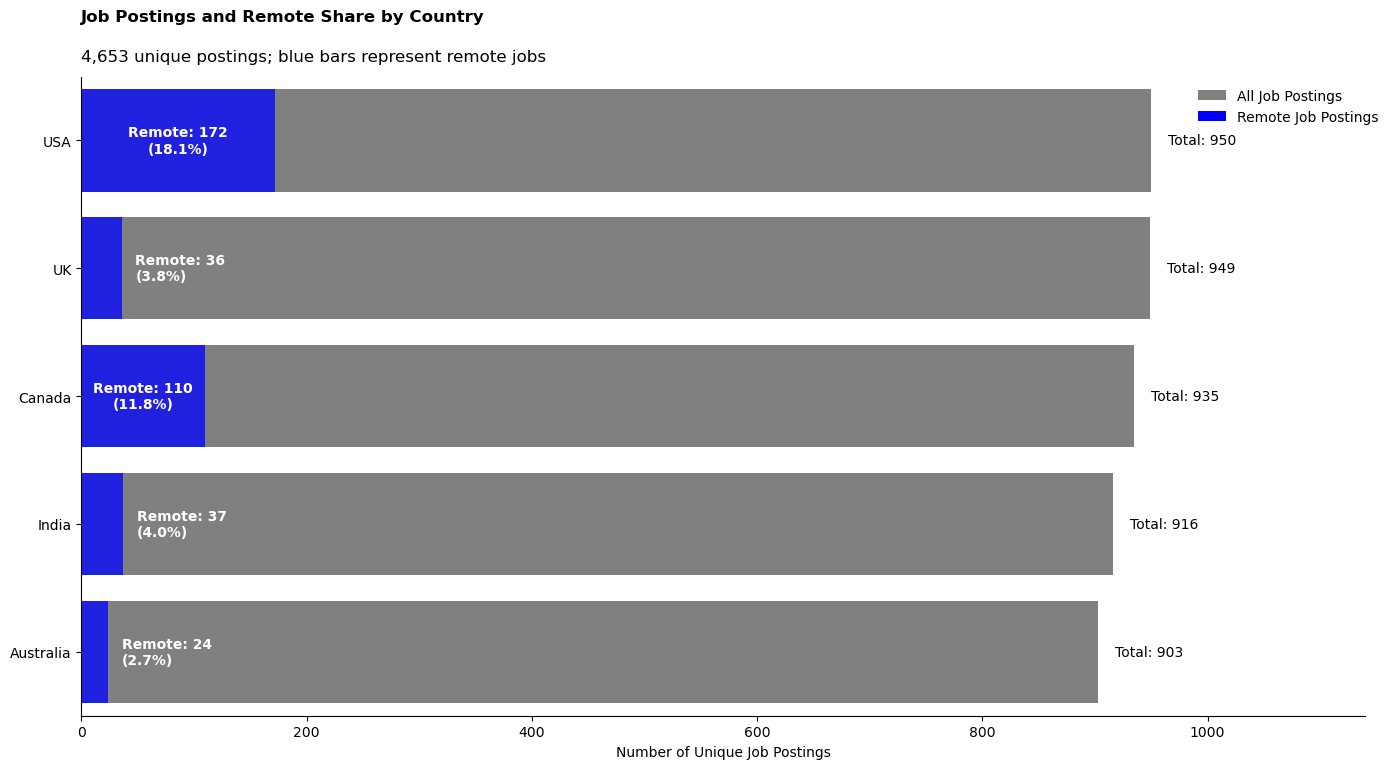

In [42]:
# Keep one record per job ID
posting_status = (
    silver[["job_id", "country", "is_remote"]]
    .drop_duplicates(subset="job_id")
    .copy()
)


# Standardize the different possible remote-status formats
remote_values = (
    posting_status["is_remote"]
    .astype("string")
    .str.strip()
    .str.lower()
)

remote_mapping = {
    "true": True,
    "false": False,
    "1": True,
    "0": False,
    "yes": True,
    "no": False,
}

posting_status["remote_flag"] = (
    remote_values.map(remote_mapping)
)


# Count total and remote postings by country
remote_by_country = (
    posting_status.groupby("country")
    .agg(
        total_postings=("job_id", "size"),
        remote_postings=("remote_flag", "sum"),
    )
    .assign(
        remote_share_pct=lambda frame: (
            100
            * frame["remote_postings"]
            / frame["total_postings"]
        )
    )
    .sort_values(
        "total_postings",
        ascending=False
    )
    .reset_index()
)

display(remote_by_country.round(2))


# Create the chart
fig, ax = plt.subplots(figsize=(14, 6))


# Grey bars represent all job postings
sns.barplot(
    data=remote_by_country,
    x="total_postings",
    y="country",
    color="grey",    
    ax=ax,
)


# Blue bars represent remote job postings
sns.barplot(
    data=remote_by_country,
    x="remote_postings",
    y="country",
    color="blue",
    ax=ax,
)


# Add labels
for position, row in remote_by_country.iterrows():

    # Total posting count
    ax.text(        
        row["total_postings"] + 15,
        position,
        f"Total: {int(row['total_postings']):,}",
        ha="left",
        va="center",
        color="black",
        fontsize=10,
    )

    # Position remote label according to bar length
    remote_count = row["remote_postings"]

    if remote_count >= 80:
        label_x = remote_count / 2
        label_alignment = "center"
        label_color = "white"
    else:
        label_x = remote_count + 12
        label_alignment = "left"
        label_color = "white"
        
    ax.text(        
        label_x,
        position,
        (
            f"Remote: {int(row['remote_postings']):,}\n"
            f"({row['remote_share_pct']:.1f}%)"
        ),
        ha=label_alignment,
        va="center",
        color=label_color,
        fontsize=10,
        fontweight="bold",
    )


# Format the chart
ax.set_title(
    "Job Postings and Remote Share by Country",
    loc="left",
    weight="bold",
    pad=40,
)

ax.set_xlabel("Number of Unique Job Postings")
ax.set_ylabel("")

ax.set_xlim(
    0,
    remote_by_country["total_postings"].max() * 1.20
)

# Add subtitle
ax.text(
    0,
    1.02,
    (
        f"{len(posting_status):,} unique postings; "
        "blue bars represent remote jobs"
    ),
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=12,
    color="black",
)


# Place legend outside the chart
legend_items = [
    Patch(
        facecolor="grey",        
        label="All Job Postings"
    ),
    Patch(
        facecolor="blue",        
        label="Remote Job Postings"
    ),
]

ax.legend(
    handles=legend_items,
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.02, 1),
)

sns.despine(ax=ax)

# Reserve space on the right for the outside legend
fig.tight_layout(
    rect=[0, 0, 1, 1.3]
)


# Save the chart
fig.savefig(
    FIGURE_DIR / "02_job_postings_and_remote_share.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

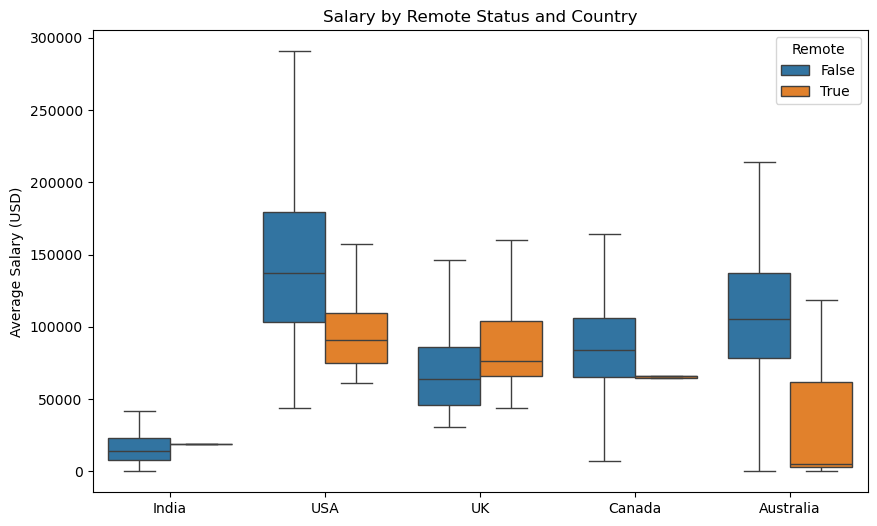

In [43]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=training_candidates,
    x="country",
    y="salary_avg_usd",
    hue="is_remote",    
    showfliers=False
)

plt.title("Salary by Remote Status and Country")
plt.ylabel("Average Salary (USD)")
plt.xlabel("")
plt.legend(title="Remote")
plt.show()

,country,total_postings,salary_postings,coverage_pct
0,USA,950,950,100.00
1,UK,949,949,100.00
2,Canada,935,238,25.45
3,India,916,56,6.11
4,Australia,903,95,10.52


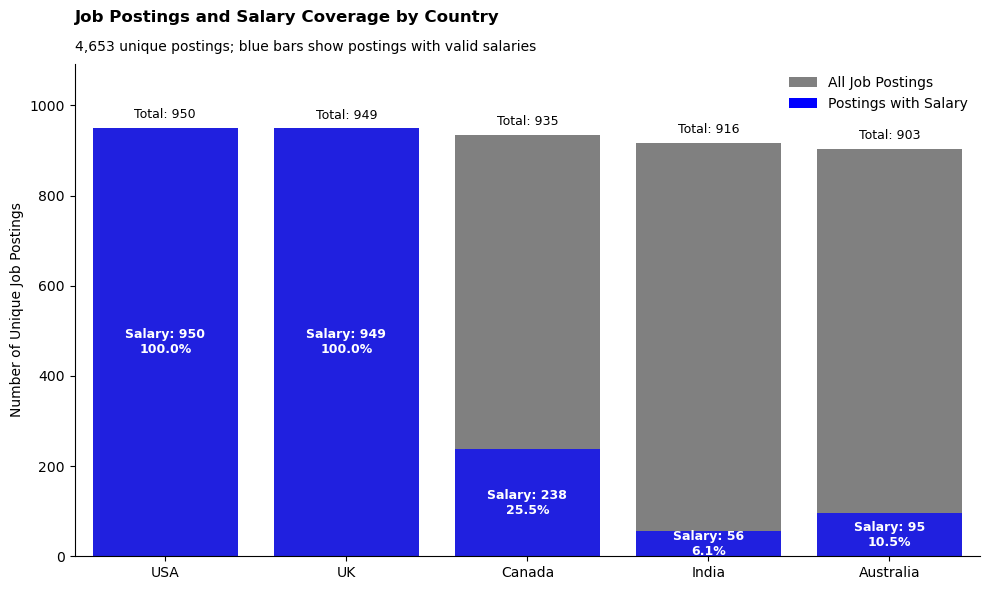

In [44]:
# Keep one record per job ID and identify salary availability
posting_status = (
    silver[["job_id", "country", "salary_avg_usd"]]
    .drop_duplicates(subset="job_id")
    .copy()
)

posting_status["has_salary"] = (
    posting_status["salary_avg_usd"].notna()
    & posting_status["salary_avg_usd"].gt(0)
)


# Count total postings and postings with salaries
coverage_by_country = (
    posting_status.groupby("country")
    .agg(
        total_postings=("job_id", "size"),
        salary_postings=("has_salary", "sum"),
    )
    .assign(
        coverage_pct=lambda frame: (
            100
            * frame["salary_postings"]
            / frame["total_postings"]
        )
    )
    .sort_values(
        "total_postings",
        ascending=False
    )
    .reset_index()
)

display(coverage_by_country.round(2))


# Create the chart
fig, ax = plt.subplots(figsize=(10, 6))

# Background bars represent all job postings
sns.barplot(
    data=coverage_by_country,
    x="country",
    y="total_postings",
    color="grey",
    ax=ax,
)

# Foreground bars represent postings with salary information
sns.barplot(
    data=coverage_by_country,
    x="country",
    y="salary_postings",
    color="BLUE",
    ax=ax,
)


# Add labels
for position, row in coverage_by_country.iterrows():

    # Total posting count above each bar
    ax.text(
        position,
        row["total_postings"] + 15,
        f"Total: {int(row['total_postings']):,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=9,
    )

    # Salary count and coverage inside the blue bar
    ax.text(
        position,
        row["salary_postings"] / 2,
        (
            f"Salary: {int(row['salary_postings']):,}\n"
            f"{row['coverage_pct']:.1f}%"
        ),
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold",
    )


# Chart formatting
ax.set_title(
    "Job Postings and Salary Coverage by Country",
    loc="left",
    weight="bold",
    pad=30,
)

ax.set_xlabel("")
ax.set_ylabel("Number of Unique Job Postings")

ax.set_ylim(
    0,
    coverage_by_country["total_postings"].max() * 1.15
)

ax.text(
    0,
    1.02,
    (
        f"{len(posting_status):,} unique postings; "
        "blue bars show postings with valid salaries"
    ),
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color="black",
)


# Create a clear legend
legend_items = [
    Patch(
        facecolor="grey",
        label="All Job Postings"
    ),
    Patch(
        facecolor="blue",        
        label="Postings with Salary"
    ),
]

ax.legend(
    handles=legend_items,
    frameon=False,
    loc="upper right"
)

sns.despine(ax=ax)
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "01_job_postings_and_salary_coverage.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

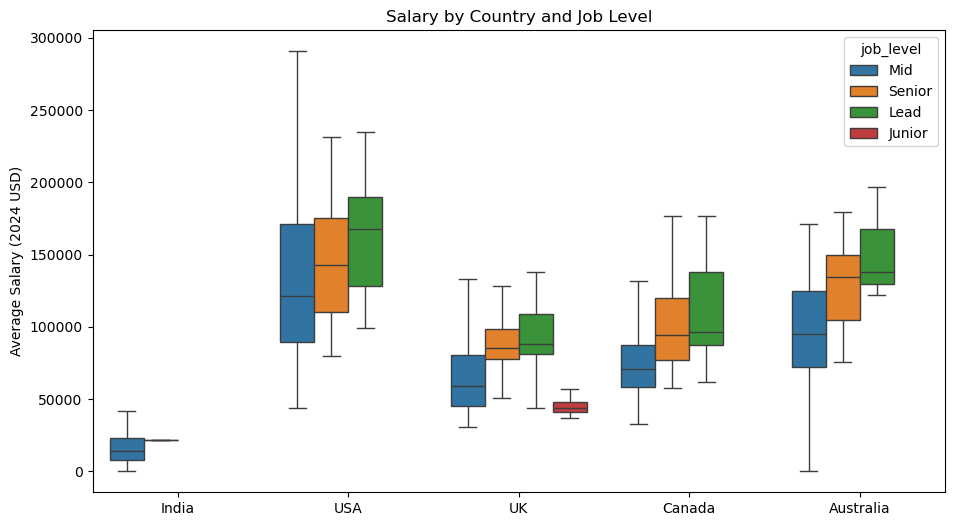

In [45]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=training_candidates,
    x="country",
    y="salary_avg_usd",
    hue="job_level",    
    showfliers=False
)

plt.title("Salary by Country and Job Level")
plt.ylabel("Average Salary (2024 USD)")
plt.xlabel("")
plt.show()

### Feature Engineering
Create:
- salary_range
- is_senior flag
- experience_tier bucket
- top skill binary flag

#### Create salary_range

In [53]:
# A salary range can only be calculated when both bounds exist
complete_salary_range = (
    silver[
        ["salary_min_usd", "salary_max_usd"]
    ]
    .notna()
    .all(axis=1)
)


# Calculate the salary range in USD
silver["salary_range_usd"] = (
    silver["salary_max_usd"]
    .sub(silver["salary_min_usd"])
    .where(complete_salary_range)
)


# Flag negative ranges as invalid
silver["salary_range_invalid"] = (
    complete_salary_range
    & silver["salary_range_usd"].lt(0)
)


print(
    "Rows with a calculated salary range:",
    silver["salary_range_usd"].notna().sum(),
)

print(
    "Rows with an invalid negative salary range:",
    silver["salary_range_invalid"].sum(),
)


# A negative range should not remain after salary cleaning
assert not silver["salary_range_invalid"].any(), (
    "At least one maximum salary is below its minimum salary."
)

Rows with a calculated salary range: 2284
Rows with an invalid negative salary range: 0


#### Validate salary_avg as midpoint of min and max

In [55]:
complete_salary_triplet = (
    silver[
        [
            "salary_min_usd",
            "salary_avg_usd",
            "salary_max_usd",
        ]
    ]
    .notna()
    .all(axis=1)
)


silver["salary_midpoint_usd_qa"] = (
    (
        silver["salary_min_usd"]
        + silver["salary_max_usd"]
    )
    / 2
).where(complete_salary_triplet)


silver["salary_midpoint_gap_usd_qa"] = (
    silver["salary_avg_usd"]
    - silver["salary_midpoint_usd_qa"]
).abs()


midpoint_mismatch = (
    complete_salary_triplet
    & ~np.isclose(
        silver["salary_avg_usd"],
        silver["salary_midpoint_usd_qa"],
        rtol=1e-7,
        atol=0.01,
    )
)


print(
    "Salary-average midpoint disagreements:",
    midpoint_mismatch.sum(),
)

Salary-average midpoint disagreements: 0


#### Salary_range_summary

In [56]:
salary_range_summary = (
    silver.loc[
        silver["salary_range_usd"].notna()
    ]
    .groupby(
        ["country", "job_level"],
        observed=True,
    )
    .agg(
        salary_records=(
            "salary_range_usd",
            "size",
        ),
        median_salary_range_usd=(
            "salary_range_usd",
            "median",
        ),
        mean_salary_range_usd=(
            "salary_range_usd",
            "mean",
        ),
    )
    .round(2)
)


display(salary_range_summary)

salary_records  median_salary_range_usd  \
country   job_level                                            
Australia Lead                    3                13,157.89   
          Mid                    72                13,157.89   
          Senior                 20                11,513.16   
Canada    Lead                   12                21,897.81   
          Mid                   152                18,248.18   
          Senior                 70                26,277.37   
India     Mid                    55                 8,366.20   
          Senior                  1                19,122.74   
UK        Junior                 40                     0.00   
          Lead                   51                     0.00   
          Mid                   747                     0.00   
          Senior                111                     0.00   
USA       Lead                   33                     0.00   
          Mid                   856                     0.00   
          Senior                 61                     0.00   

                     mean_salary_range_usd  
country   job_level                         
Australia Lead                   10,087.72  
          Mid                    15,113.95  
          Senior                 15,495.07  
Canada    Lead                   27,184.49  
          Mid                    21,655.15  
          Senior                 28,453.94  
India     Mid                    10,512.11  
          Senior                 19,122.74  
UK        Junior                  3,717.95  
          Lead                    2,388.13  
          Mid                     6,569.45  
          Senior                  2,114.55  
USA       Lead                    3,818.18  
          Mid                         0.00  
          Senior                      0.00

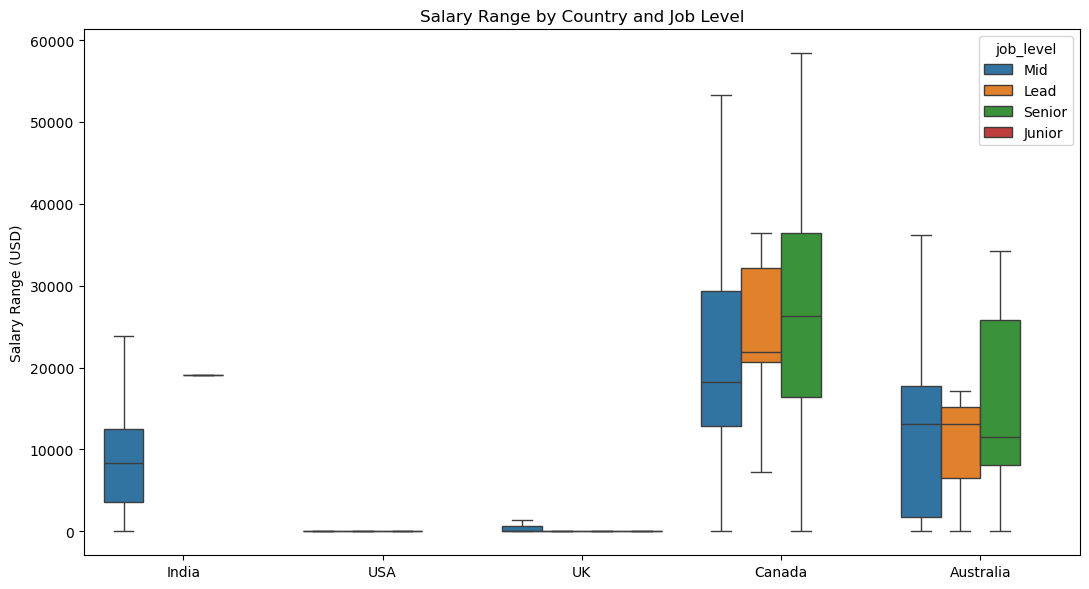

In [57]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=silver,
    x="country",
    y="salary_range_usd",
    hue="job_level",
    showfliers=False,
)

plt.title("Salary Range by Country and Job Level")
plt.xlabel("")
plt.ylabel("Salary Range (USD)")
plt.tight_layout()
plt.show()

**Engineer Salary Range**

`salary_range_usd` measures the difference between the maximum and minimum reported salaries:

**Salary range = Maximum salary − Minimum salary**

The feature is calculated after currency conversion so that salary ranges are comparable across countries.

Because `salary_avg` is calculated from `salary_min` and `salary_max`, the range is closely connected to the target. It is therefore retained in the Silver layer for validation and EDA but excluded from the final model features to prevent target-related leakage and prediction-time availability problems.

#### Seniority flag

In [61]:
# Confirm that job_level contains only expected categories
expected_job_levels = {
    "Junior",
    "Mid",
    "Senior",
    "Lead",
}

assert set(
    silver["job_level"].dropna().unique()
) == expected_job_levels


# Senior and Lead roles receive 1;
# Junior and Mid roles receive 0.
silver["is_senior"] = (
    silver["job_level"]
    .isin(["Senior", "Lead"])
    .astype("int8")
)


# Give the two groups readable segment labels
silver["salary_segment"] = (
    silver["is_senior"]
    .map(
        {
            0: "Standard",
            1: "Premium",
        }
    )
)

In [62]:
seniority_check = pd.crosstab(
    silver["job_level"],
    silver["is_senior"],
    margins=True,
)


display(seniority_check)


assert (
    silver.loc[
        silver["job_level"].isin(["Senior", "Lead"]),
        "is_senior",
    ]
    .eq(1)
    .all()
)


assert (
    silver.loc[
        silver["job_level"].isin(["Junior", "Mid"]),
        "is_senior",
    ]
    .eq(0)
    .all()
)

is_senior,0,1,All
job_level,,,
Junior,72,0,72
Lead,0,293,293
Mid,3442,0,3442
Senior,0,846,846
All,3514,1139,4653


**Create Seniority Flag**

The `is_senior` feature groups `Senior` and `Lead` positions into the project’s **Premium** segment. `Junior` and `Mid` positions form the **Standard** segment.

This simplifies comparisons of salary patterns and model accuracy between higher-seniority and standard roles.

#### Experience_tier flag

In [97]:
# Create the experience_tier
df["experience_tier"] = pd.cut(
    df["experience_required"],
    bins=[0, 2, 5, 10, 35, float("inf")],
    labels=[
        "Entry",
        "Intermediate",
        "Experienced",
        "Highly Experienced",
        "Flagged"
    ],
    include_lowest=True,
)

df["experience_tier"].value_counts(dropna=False)

experience_tier
NaN                   4221
Intermediate           159
Experienced            157
Highly Experienced      80
Entry                   36
Flagged                  0
Name: count, dtype: int64

#### One-Hot Encode the Required Categorical Features

`job_level`, `country`, and `is_remote` are categorical predictors. They are one-hot encoded inside the modelling pipeline after the train/test split.

The encoder is fitted only on the training data to prevent test-data information from influencing preprocessing. One reference category is dropped from each variable to avoid redundant dummy columns.

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# Columns required for one-hot encoding
categorical_features = [
    "job_level",
    "country",
    "is_remote",
]


# Include num_skills without encoding it
numeric_features = [
    "num_skills",
]


feature_columns = (
    categorical_features
    + numeric_features
)


# Create a separate feature table.
# The original df remains unchanged.
X = df[feature_columns].copy()


# Split before fitting the encoder
X_train, X_test = train_test_split(
    X,
    test_size=0.20,
    random_state=42,
    stratify=X["country"],
)

In [47]:
print(df.columns.tolist())

['job_id', 'job_title', 'company', 'location', 'salary_min', 'salary_max', 'description', 'country', 'search_keyword', 'experience_required', 'degree_required', 'skills', 'num_skills', 'job_level', 'is_remote', 'salary_avg', 'has_salary', 'experience_required_clean', 'experience_missing', 'experience_rejected', 'experience_tier']


In [49]:
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False,
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)


encoding_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        )
    ]
)

In [50]:
# Learn categories from training data only
X_train_encoded_array = (
    encoding_pipeline.fit_transform(X_train)
)


# Apply the learned encoding to test data
X_test_encoded_array = (
    encoding_pipeline.transform(X_test)
)


# Retrieve the new column names
encoded_feature_names = (
    encoding_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)


# Convert the arrays into readable DataFrames
X_train_encoded = pd.DataFrame(
    X_train_encoded_array,
    columns=encoded_feature_names,
    index=X_train.index,
)


X_test_encoded = pd.DataFrame(
    X_test_encoded_array,
    columns=encoded_feature_names,
    index=X_test.index,
)


display(X_train_encoded.head())

,job_level_Lead,job_level_Mid,job_level_Senior,country_Canada,country_India,country_UK,country_USA,is_remote_True,num_skills
2270,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
3744,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
2283,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
3944,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4563,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [51]:
print("Original columns:")
print(feature_columns)

print("\nEncoded columns:")
print(X_train_encoded.columns.tolist())

print("\nTraining shape:", X_train_encoded.shape)
print("Test shape:", X_test_encoded.shape)

Original columns:
['job_level', 'country', 'is_remote', 'num_skills']

Encoded columns:
['job_level_Lead', 'job_level_Mid', 'job_level_Senior', 'country_Canada', 'country_India', 'country_UK', 'country_USA', 'is_remote_True', 'num_skills']

Training shape: (3722, 9)
Test shape: (931, 9)
